## Исследование устойчивости нейросетевых моделей к методам сжатия: квантование и отбрасывание

### Введение и цель исследования
В современной практике разработки внедрение тяжелых нейросетей на устройства с ограниченными вычислительными ресурсами (мобильные телефоны, IoT, микроконтроллеры) требует жесткого сжатия моделей. Однако оптимизация размера часто имеет цену в виде снижения качества работы и потери надежности.

**Цель проекта:** Исследовать влияние методов сжатия (квантования и отбрасывания связей) на качество работы полносвязной нейронной сети, оценивая не только стандартную метрику точности, но и уверенность модели, а также её устойчивость к состязательным атакам.

### Данные
* **Датасет:** Классический `MNIST` (60 000 обучающих, 5 000 тестовых, 4 000 валидационных и 1 000 калибровочных объектов).
* **Признаки:** Изображения $28 \times 28$ пикселей в оттенках серого, векторизованные в 784 входных признака.

### Модель
* **Архитектура:** Полносвязная многослойная сеть: Вход (784) $\to$ Скрытый слой 1 (256) $\to$ Скрытый слой 2 (128) $\to$ Выход (10 логитов).
* **Активации:** Код поддерживает функции `tanh` и `ReLU`.

### Внутренние искажения (Сжатие модели)
* **Квантование:** 8, 4, 2 бита и Sign-only (1 бит). Квантование только весов (`weights`) против совместного квантования весов и активаций (`both`).
* **Протоколы квантования:** PTQ (Post-Training Quantization) и QAT (Quantization-Aware Training через Straight-Through Estimator).
* **Прунинг (Отбрасывание связей):**
  * По модулю (Magnitude).
  * По первому порядку (Gradient/Sensitivity).
  * По второму порядку (Hessian-based / Optimal Brain Damage).

### Внешние угрозы (Атаки)
* **Методы:** Fast Gradient Sign Method (FGSM) и итеративный Projected Gradient Descent (PGD).
* **Интенсивность:** Радиус возмущения $\varepsilon$ (основной - 0.1).

### Оцениваемые метрики
* **Точность:** Clean Accuracy (на исходных данных) и Robust Accuracy (в условиях состязательного шума).
* **Уверенность модели:** Запас логитов (Margin) $m(x)$, Индекс разреженности границ (MSI) и Хрупкость худшего класса (Worst-Class Drop).
* **Эффективность:** Эффективность сжатия бита (BSE).

### Технологии
* **Вычисления и архитектура:** `NumPy` (линейная алгебра и прямые/обратные проходы слоев).
* **Работа с данными:** `Pandas` (структурирование результатов), `scikit-learn` (загрузка датасета через `fetch_openml` и разбиение выборок).
* **Визуализация:** `Matplotlib` + `Seaborn` (статичные распределения весов и метрик), `Plotly` (интерактивные тепловые карты и многопанельные дашборды сравнения моделей).
* **Системные утилиты:** Стандартная библиотека Python (`os` для работы с файловой системой, `copy` для клонирования весов моделей, `itertools` для генерации комбинаций параметров сетки экспериментов).

In [1]:
import os
import copy
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Спец. настройки графиков
sns.set_theme(style='darkgrid', palette='bright')
%config InlineBackend.figure_format = 'retina'

SEED = 451
np.random.seed(SEED)

### Загрузка, подготовка и разбиение данных

Загружаем классический датасет **MNIST** (изображения рукописных цифр, развернутые в векторы из 784 признаков) и масштабируем интенсивность пикселей в диапазон [0, 1] для стабильной работы градиентных методов.

Для чистоты экспериментов исходный датасет разбивается на четыре выборки:
* **Обучающая (Train - 60 000 объектов):** используется для базовой настройки весов исходной FP32-модели.
* **Тестовая (Test - 5 000 объектов):** финальный аудит точности и точности при атаке после процедур сжатия.
* **Валидационная (Validation - 4 000 объектов):** необходима для мониторинга метрик и предотвращения переобучения в процессе дообучения.
* **Калибровочная (Calibration - 1 000 объектов):** выделенный набор для алгоритмов PTQ, позволяющий рассчитать оптимальные шаги квантования.

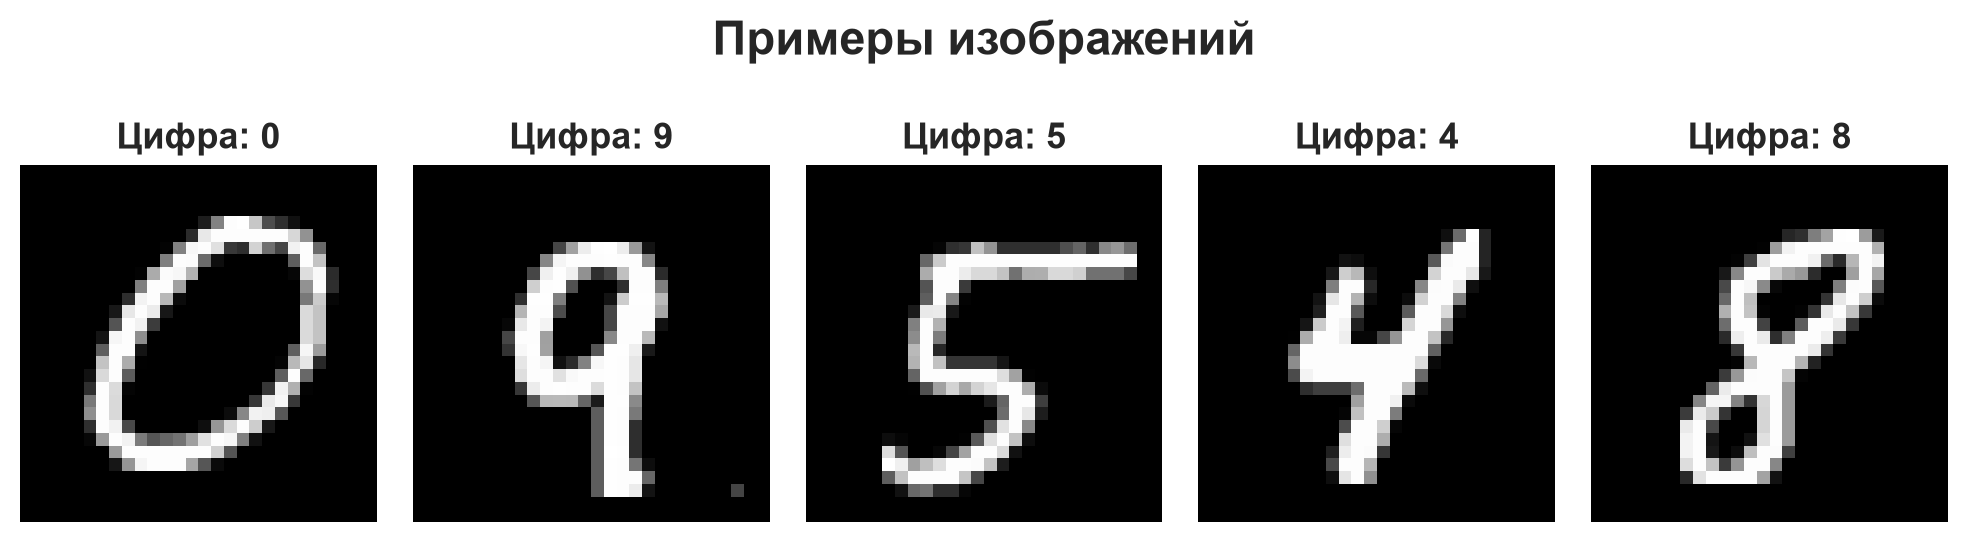

In [2]:
# Установка MNIST (при первом запуске занимает примерно 1 минуту)
data = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = data.data, data.target.astype(np.uint8)

# мин-макс нормализация в [0, 1]
X = X / 255.0

# Берем 60 000 обучающих объектов
X_train, X_test_temp, y_train, y_test_temp = train_test_split(
    X, y, test_size=10000, random_state=SEED, stratify=y
)
# 5 000 на тест и 5 000 на нужды оптимизации (валидация + калибровка)
X_test, X_val_temp, y_test, y_val_temp = train_test_split(
    X_test_temp, y_test_temp, test_size=5000, random_state=SEED, stratify=y_test_temp
)
# 1 000 на калибровку, остальные 4 000 объектов на валидацию
X_val, X_calib, y_val, y_calib = train_test_split(
    X_val_temp, y_val_temp, test_size=1000, random_state=SEED, stratify=y_val_temp
)

# Выведем несколько примеров изображений цифр из MNIST
fig, axes = plt.subplots(1, 5, figsize=(10, 3))
fig.suptitle('Примеры изображений', fontweight='bold', fontsize=17, y=0.97)

np.random.seed(SEED)
t = np.random.randint(1, X.shape[0], 5) 

for i in range(5):
    image_matrix = X[t[i]].reshape(28, 28)
    axes[i].imshow(image_matrix, cmap='gray')
    axes[i].set_title(f"Цифра: {y[t[i]]}", fontweight='bold', fontsize=13)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Функция симуляции квантования

Функция `get_quantization` эмулирует прохождение непрерывных значений (весов или активаций) через дискретную сетку заданной разрядности. Код поддерживает три режима:

1. **Sign-only (1 бит):** экстремальная бинаризация. Значения сжимаются до знака ($\pm 1$), масштабированного на средний абсолютный модуль матрицы весов для минимизации ошибки аппроксимации.
2. **Асимметричное квантование (Min-Max):** проецирует диапазон значений в сетку $[0, 2^{bits} - 1]$. Оптимально для строго неотрицательных распределений (например, после активации `ReLU`).
3. **Симметричное квантование:** центрирует сетку вокруг нуля в диапазоне $[-2^{bits-1}, 2^{bits-1} - 1]$. Подходит для симметричных распределений - весов модели и активаций типа `tanh`.

In [3]:
def get_quantization(W, bits, asymmetric=False):
    # Квантование Sign-only
    if bits == 1:
        # Оптимальный коэффициент масштаба - среднее по модулю
        scale = np.mean(np.abs(W))
        if scale == 0:
            return np.zeros_like(W)
        return np.sign(W) * scale
        
    if asymmetric:
        # Мин-макс квантование, подходит для ReLU (минимум - 0)
        qmin = 0
        qmax = (2 ** bits) - 1
        alpha = np.max(W)
        if alpha <= 0: 
            return np.zeros_like(W)
    else:
        # Симметричное квантование, подходит для tanh
        qmin = -(2 ** (bits - 1))
        qmax = (2 ** (bits - 1)) - 1
        alpha = np.max(np.abs(W))
        if alpha == 0: 
            return W
    scale = alpha / qmax
    return scale * np.clip(np.round(W / scale), qmin, qmax)

### Базовая архитектура модели и механизмы сжатия

Класс `BasicModel` представляет собой трехслойную полносвязную нейронную сеть, реализованную на `NumPy`.

В архитектуру заложена поддержка экспериментов по оптимизации:
* **Управление прунингом через `self.masks`:**  
  Модель не использует избыточные внешние конфигурации для прореживания. Вместо этого состояние сети контролируется напрямую через бинарные маски весов (`self.masks`). На каждом шаге градиентного спуска обновленные веса принудительно умножаются на маски: `W *= mask`, что гарантированно удерживает удаленные связи в нулевом состоянии.

* **Симуляция квантования (PTQ и QAT):**  
  Интеграция дискретной сетки в непрерывный граф вычислений происходит на двух уровнях через словарь `self.quant_config`:
  * *Активации:* Сжимаются внутри приватного метода `_quant_act` перед передачей на следующий слой (если выбран режим `both`).
  * *Веса и Straight-Through Estimator (STE):* В режиме дообучения (QAT) модель сохраняет исходные FP32-копии весов. На прямом проходе веса квантуются для симуляции шума округления, а на обратном проходе накопленный градиент применяется к базовым FP32-весам. Это позволяет обойти проблему нулевого градиента округления.

* **Встроенный аудит уверенности:**  
  Метод `compute_metrics` прямо во время обучения рассчитывает не только базовый Accuracy, но и динамику разделяющих поверхностей: медианный запас логитов (Margin), его 10%-й квантиль для поиска наиболее хрупких объектов и индекс разреженности границ (MSI), показывающий долю объектов вблизи границы принятия решений.

In [4]:
class BasicModel:
    def __init__(
            self, input_dim=784,
            hidden_dim_1=256, hidden_dim_2=128, 
            num_classes=10, activ_func=np.tanh
        ):
        np.random.seed(SEED)

        self.input_w = np.random.normal(
            scale=2/input_dim, size=(input_dim, hidden_dim_1)
        )
        self.input_b = np.zeros(hidden_dim_1)

        self.hl_w = np.random.normal(
            scale=2/hidden_dim_1, size=(hidden_dim_1, hidden_dim_2)
        )
        self.hl_b = np.zeros(hidden_dim_2)

        self.output_w = np.random.normal(
            scale=2/hidden_dim_2, size=(hidden_dim_2, num_classes)
        )
        self.output_b = np.zeros(num_classes)

        self.num_classes = num_classes
        self.activ_func = activ_func
        self.cache = {}
        # Бинарные маски для отбрасывания (1 - связь есть, 0 - удалена)
        self.masks = {
            'input_w': np.ones_like(self.input_w),
            'hl_w': np.ones_like(self.hl_w),
            'output_w': np.ones_like(self.output_w)
        }
        # Единый конфиг квантования
        self.quant_config = {
            'bits': None,  # 8, 4, 2, 1 или None
            'target': 'weights',  # 'weights' или 'both' (веса + активации)
            'mode': None  # 'PTQ' или 'QAT'
        }

    def _softmax(self, logits):
        exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
        return exp_logits / exp_logits.sum(axis=1, keepdims=True)
    
    def _activ_func_deriv(self, A):
        if self.activ_func == np.tanh:
            return 1 - A ** 2
        return (A > 0).astype(float)
    
    def _get_logits(self, X):
        z_1 = X @ self.input_w + self.input_b
        nn_layer_1 = self._quant_act(self.activ_func(z_1))

        z_2 = nn_layer_1 @ self.hl_w + self.hl_b
        nn_layer_2 = self._quant_act(self.activ_func(z_2))

        z_3 = nn_layer_2 @ self.output_w + self.output_b
        return z_3
    
    def _quant_act(self, A):
        if (
            self.quant_config['bits'] is not None
        ) and (
            self.quant_config['target'] == 'both'
        ):
            is_relu = (self.activ_func != np.tanh)
            return get_quantization(A, self.quant_config['bits'], asymmetric=is_relu)
        return A

    def forward_prop(self, X):
        z_1 = X @ self.input_w + self.input_b
        nn_layer_1 = self._quant_act(self.activ_func(z_1))

        z_2 = nn_layer_1 @ self.hl_w + self.hl_b
        nn_layer_2 = self._quant_act(self.activ_func(z_2))

        z_3 = nn_layer_2 @ self.output_w + self.output_b
        nn_prob = self._softmax(z_3)
        self.cache = {
            'X': X, 'nn_layer_1': nn_layer_1,
            'nn_layer_2': nn_layer_2, 'nn_prob': nn_prob
        }
        return nn_prob
    
    def backward_prop(self, y_true):
        X = self.cache['X']
        nn_layer_1 = self.cache['nn_layer_1']
        nn_layer_2 = self.cache['nn_layer_2']
        nn_prob = self.cache['nn_prob']
        N = X.shape[0]

        # y_true -> Y - one-hot матрица
        Y = np.zeros_like(nn_prob)
        Y[np.arange(N), y_true] = 1.0

        # Градиенты выходного слоя (3)
        d_z_3 = (nn_prob - Y) / N
        d_output_w = nn_layer_2.T @ d_z_3
        d_output_b = np.sum(d_z_3, axis=0)

        # Градиенты скрытого слоя (2)
        d_nn_layer_2 = d_z_3 @ self.output_w.T
        d_z_2 = d_nn_layer_2 * self._activ_func_deriv(nn_layer_2)
        d_hl_w = nn_layer_1.T @ d_z_2
        d_hl_b = np.sum(d_z_2, axis=0)

        # Градиенты скрытого слоя (1)
        d_nn_layer_1 = d_z_2 @ self.hl_w.T
        d_z_1 = d_nn_layer_1 * self._activ_func_deriv(nn_layer_1)
        d_input_w = X.T @ d_z_1
        d_input_b = np.sum(d_z_1, axis=0)

        return {
            'input_w': d_input_w, 'input_b': d_input_b,
            'hl_w': d_hl_w, 'hl_b': d_hl_b,
            'output_w': d_output_w, 'output_b': d_output_b
        }
    
    def compute_metrics(self, X, y_true):
        logits = self._get_logits(X)
        pred_classes = np.argmax(logits, axis=1)
        N = X.shape[0]

        # Accuracy
        accuracy = np.mean(pred_classes == y_true)
        # Запас логитов (Margin)
        correct_logits = logits[np.arange(N), y_true]
        mask_logits = logits.copy()
        mask_logits[np.arange(N), y_true] = -np.inf
        max_wrong_logits = np.max(mask_logits, axis=1)
        margins = correct_logits - max_wrong_logits
        median_margin = np.median(margins)
        # 10%-й квантиль для поиска уязвимых объектов
        q10_margin = np.quantile(margins, 0.1) 
        # Индекс разреженности границ (MSI): процент объектов в зоне 0 < m(x) < 0.5
        msi = np.mean((margins > 0) & (margins < 0.5)) * 100
        # Локальная точность по каждому из 10 классов
        class_accuracies = {}
        for c in range(self.num_classes):
            class_mask = (y_true == c)
            if np.sum(class_mask) > 0:
                class_accuracies[c] = np.mean(pred_classes[class_mask] == y_true[class_mask])
            else:
                class_accuracies[c] = 0.0
        
        return {
            'accuracy': accuracy,
            'margin': median_margin,
            'q10_margin': q10_margin,
            'msi': msi,
            'class_accuracies': class_accuracies
        }

    def fit(self, X, y, batch_size=100, lr=0.1, max_epochs=100):
        N = X.shape[0]

        for epoch in range(max_epochs):
            # Перемешивание выборки в начале каждой эпохи
            ind = np.arange(N)
            np.random.shuffle(ind)
            X_shf = X[ind]
            y_shf = y[ind]

            for i in range(0, N, batch_size):
                X_batch = X_shf[i : i+batch_size]
                y_batch = y_shf[i : i+batch_size]
                
                # QAT симулирует квантование весов во время обучения
                if (
                    self.quant_config['mode'] == 'QAT'
                ) and (
                    self.quant_config['bits'] is not None
                ):
                    orig_w1 = self.input_w.copy()
                    orig_w2 = self.hl_w.copy()
                    orig_w3 = self.output_w.copy()
                    self.input_w = get_quantization(self.input_w, self.quant_config['bits'])
                    self.hl_w = get_quantization(self.hl_w, self.quant_config['bits'])
                    self.output_w = get_quantization(self.output_w, self.quant_config['bits'])
                
                # Прямой проход
                self.forward_prop(X_batch)
                # Обратный проход
                grad = self.backward_prop(y_batch)

                # Если был включен QAT: Возвращаем float-копии назад, чтобы обновить их градиентом (STE)
                if (
                    self.quant_config['mode'] == 'QAT'
                ) and (
                    self.quant_config['bits'] is not None
                ):
                    self.input_w, self.hl_w, self.output_w = orig_w1, orig_w2, orig_w3
                
                # Обновление параметров (Градиентный спуск)
                self.input_w -= lr * grad['input_w']
                self.input_b -= lr * grad['input_b']
                self.hl_w -= lr * grad['hl_w']
                self.hl_b -= lr * grad['hl_b']
                self.output_w -= lr * grad['output_w']
                self.output_b -= lr * grad['output_b']

                # Принудительное удержание отбрасывания
                self.input_w *= self.masks['input_w']
                self.hl_w *= self.masks['hl_w']
                self.output_w *= self.masks['output_w']

            # Промежуточные результаты 
            metrics = self.compute_metrics(X, y)
            print(
                f"Эпоха {epoch+1:02d}/{max_epochs} | " +
                f"Accuracy: {metrics['accuracy']:.4f} | " +
                f"MSI: {metrics['msi']:.2f}% | " +
                f"Запас логитов: {metrics['margin']:.3f}"
            )

    def predict(self, X):
        logits = self._get_logits(X)
        return np.argmax(logits, axis=1)

### Применение сжатия (квантование и прунинг)

Этот блок содержит функции для выполнения базовых преобразований над параметрами сети:
* `apply_quantization`
Управляет процессом дискретизации. При вызове в режиме **PTQ** (Post-Training Quantization) функция выполняет квантование весов и отключает дальнейшую симуляцию. При работе в режиме **QAT** функция лишь инициализирует конфигурационный словарь модели, сигнализируя процедуре обучения о необходимости включения симуляции дискретизации на прямом и обратном проходах.
* `apply_pruning`
Рассчитывает и формирует маски отсечения весов по трем критериям:
1. **Magnitude:** $\vert{}W\vert{}$ - простейшее отбрасывание весов с наименьшей абсолютной величиной.
2. **Gradient (1-й порядок):** $\vert{}W \cdot g\vert{}$ - оценка чувствительности, взвешивающая величину веса на средний накопленный градиент $\nabla_W L$ по калибровочной выборке.
3. **Hessian-based / OBD (2-й порядок):** $\frac{1}{2} H_{ii} W^2$ - аппроксимация метода Optimal Brain Damage. Диагональные элементы Гессиана $H_{ii}$ оцениваются через эмпирическую матрицу информации Фишера (накоплением квадратов градиентов $g^2$ на калибровочных объектах).

Порог отсечения вычисляется индивидуально для каждого слоя как квантиль распределения важности, соответствующий требуемой доле удаления (`ratio`).

In [5]:
def apply_quantization(model, bits=4, target='weights', mode='PTQ'):
    q_model = copy.deepcopy(model)
    q_model.quant_config = {'bits': bits, 'target': target, 'mode': mode}
    
    if mode == 'PTQ':
        # Перезаписываем веса
        q_model.input_w = get_quantization(q_model.input_w, bits)
        q_model.hl_w = get_quantization(q_model.hl_w, bits)
        q_model.output_w = get_quantization(q_model.output_w, bits)
        q_model.quant_config['mode'] = None
        
    return q_model

def apply_pruning(model, pruning_type='magnitude', ratio=0.3, X_calib=None, y_calib=None):
    pruned_model = copy.deepcopy(model)
    w_names = ['input_w', 'hl_w', 'output_w']
    accumulated_grad = {name: np.zeros_like(getattr(pruned_model, name)) for name in w_names}
    accumulated_hess = {name: np.zeros_like(getattr(pruned_model, name)) for name in w_names}
    
    if pruning_type in ['gradient', 'hessian']:
        if X_calib is None or y_calib is None:
            raise ValueError(
                "Для градиентных методов отбрасывания нужны X_calib и y_calib!"
            )
        num_samples = X_calib.shape[0]
        for idx in range(num_samples):
            X_sample = X_calib[idx : idx + 1]
            y_sample = y_calib[idx : idx + 1]
            
            pruned_model.forward_prop(X_sample)
            grad_sample = pruned_model.backward_prop(y_sample)
            
            for name in w_names:
                # Для первого порядка копируем/копим обычный градиент
                accumulated_grad[name] += grad_sample[name]
                # Для Гессиана копим КВАДРАТЫ градиентов каждого объекта отдельно
                accumulated_hess[name] += grad_sample[name] ** 2
        
        # Усредняем по размеру калибровочной выборки
        for name in w_names:
            accumulated_grad[name] /= num_samples
            accumulated_hess[name] /= num_samples

    for name in w_names:
        W = getattr(pruned_model, name)
        # Расчет карт важности весов
        if pruning_type == 'magnitude':
            score = np.abs(W)
        elif pruning_type == 'gradient':
            score = np.abs(W * accumulated_grad[name])
        elif pruning_type == 'hessian':
            # 0.5 * H_ii * W^2
            score = 0.5 * accumulated_hess[name] * (W ** 2)
            
        # Находим глобальный порог для слоя по квантилю
        threshold = np.quantile(score, ratio)
        mask = (score >= threshold).astype(float)
        # Отбрасываем
        pruned_model.masks[name] = mask
        setattr(pruned_model, name, W * mask)
        
    return pruned_model

### Расчет теоретического размера модели и степени сжатия

Функция `model_size` предназначена для аналитической оценки эффективности сжатия (BSE/Compression Ratio). Она рассчитывает физический вес модели в памяти на основе следующих допущений:
* **Векторы сдвигов (Biases):** Не подвергаются квантованию и прунингу, всегда учитываются как 32-битные вещественные числа (FP32).
* **Матрицы весов (Weights):** Хранятся с разрядностью `w_bits` (8, 4, 2 или 1 бит), определенной в конфигурации квантования.
* **Учет разреженности:** При наличии маски прунинга учитываются только физически сохраненные (ненулевые) веса. Это эмулирует хранение модели в разреженных форматах, где отброшенные связи не занимают дисковое пространство (оверхед на индексацию структуры разреженности в расчете для простоты опущен).

Функция возвращает общее число параметров, количество активных связей, размер модели в байтах и итоговый коэффициент сжатия относительно базовой FP32-версии.

In [6]:
def model_size(model):
    w_names = ['input_w', 'hl_w', 'output_w']
    b_names = ['input_b', 'hl_b', 'output_b']

    # Извлекаем конфигурации квантования
    quant_config = getattr(model, 'quant_config', {}) or {}
    # Извлекаем маски прунинга
    masks = getattr(model, 'masks', {}) or {}

    # Общее кол-во параметров сети (включая сдвиги)
    total_params = sum(getattr(model, name).size for name in (w_names + b_names))
    # Кол-во численно ненулевых параметров
    nonzero_params = sum(np.count_nonzero(getattr(model, name)) for name in (w_names + b_names))

    # Разрядность квантования весов (по умолчанию 32 бита)
    w_bits = quant_config.get('bits') if quant_config.get('bits') else 32
    
    # Сдвиги всегда остаются 32-битными плотными векторами
    total_b_count = sum(getattr(model, name).size for name in b_names)

    # Вычисляем кол-во весов, которые мы храним
    stored_w_count = 0
    for name in w_names:
        weight_matrix = getattr(model, name)
        if name in masks:
            stored_w_count += np.count_nonzero(masks[name])
        else:
            stored_w_count += weight_matrix.size

    # Итоговый размер в битах
    memory_bits = int(stored_w_count * w_bits + total_b_count * 32)
    memory_bytes = memory_bits / 8

    # Базовый размер float32 модели для расчета сжатия
    baseline_bits = total_params * 32
    compression_ratio = baseline_bits / memory_bits if memory_bits > 0 else 1.0

    return {
        "total_params": total_params,
        "nonzero_params": nonzero_params,
        "memory_bits": memory_bits,
        "memory_bytes": memory_bytes,
        "compression_ratio": compression_ratio
    } 

### Генерация состязательных примеров (Adversarial Attacks)

Функция `generate_advers_examples` реализует алгоритмы градиентного поиска состязательных возмущений по входным данным:

1. **FGSM (Fast Gradient Sign Method):**  
   Одношаговый метод генерации шума. Возмущение строится вдоль знака градиента функции потерь $L$ относительно входного вектора объектов $X$:
   $$X_{\text{adv}} = \text{clip}\left(X + \varepsilon \cdot \text{sign}\left(\nabla_X L(\theta, X, y)\right), 0, 1\right)$$
   Где $\varepsilon$ - заданный радиус состязательного возмущения, ограничивающий силу атаки.

2. **PGD (Projected Gradient Descent):**  
   Итеративный вариант атаки, представляющий собой многократный градиентный спуск с шагом $\alpha$ и последующим проецированием полученного возмущения обратно в $\varepsilon$-окрестность (в смысле метрики $L_{\infty}$) исходного примера $X$:
   $$X^{t+1} = \text{clip}\left(\text{clip}\left(X^t + \alpha \cdot \text{sign}\left(\nabla_{X^t} L(\theta, X^t, y)\right), X - \varepsilon, X + \varepsilon\right), 0, 1\right)$$
   Метод PGD считается одной из наиболее мощных атак первого порядка.

Расчет градиента функции потерь по входам ($\nabla_X L$) реализован внутри приватного метода `get_gradient` с помощью ручного бэкпропагейшна от выходного слоя к входному слою $X$ по цепочечному правилу дифференцирования.

In [7]:
def generate_advers_examples(model, X, y_true, attack_config):
    if (not attack_config) or (attack_config.get('type') == 'none'):
        return X
        
    attack_type = attack_config.get('type', 'FGSM').upper()
    eps = attack_config.get('eps', 0.1)
    N = X.shape[0]
    
    def get_gradient(X):
        nn_prob = model.forward_prop(X)
        Y = np.zeros_like(nn_prob)
        Y[np.arange(N), y_true] = 1.0
        
        d_z_3 = (nn_prob - Y) / N
        d_nn_layer_2 = d_z_3 @ model.output_w.T
        d_z_2 = d_nn_layer_2 * model._activ_func_deriv(model.cache['nn_layer_2'])
        d_nn_layer_1 = d_z_2 @ model.hl_w.T
        d_z_1 = d_nn_layer_1 * model._activ_func_deriv(model.cache['nn_layer_1'])
        return d_z_1 @ model.input_w.T

    if attack_type == 'FGSM':
        dX = get_gradient(X)
        X_nois = X + eps * np.sign(dX)
        return np.clip(X_nois, 0.0, 1.0)
        
    elif attack_type == 'PGD':
        alpha = attack_config.get('alpha', 0.01)
        iters = attack_config.get('iters', 10)
        X_nois = X.copy()
        for t in range(iters):
            dX = get_gradient(X_nois)
            X_nois = X_nois + alpha * np.sign(dX)
            X_nois = np.clip(X_nois, X - eps, X + eps)
            X_nois = np.clip(X_nois, 0.0, 1.0)
        return X_nois
        
    return X

### Комплексная оценка качества и устойчивости модели

Функция `evaluate_model` выполняет глубокий аудит модели на тестовом множестве, агрегируя поученные показатели в три ключевые группы:
1. Точность классификации и поклассовый анализ
   * **Accuracy / Robust Accuracy:** Метрики точности и точности под атакой.
   * **Worst-Class Adversarial Drop:** Измеряет максимальное падение точности среди всех 10 классов под атакой.
   * **Worst-Class Compression Drop:** Показывает максимальную потерю точности на конкретном классе, вызванную сжатием весов в сравнении с исходной моделью.
2. Геометрия разделяющих поверхностей (Margin Analysis)
  Запас уверенности модели для классифицируемого объекта определяется как разность между логитом истинного класса и максимальным логитом среди всех неверных классов: $m(x) = z_{\text{correct}} - \max_{j \neq \text{correct}} z_j$.
     * **Median Margin:** Отражает общую уверенность модели в своих правильных решениях (как на чистых данных, так и под атакой).
     * **Margin Q10 (10%-й квантиль):** Метрика выявления уязвимых объектов. Низкие или отрицательные значения указывают на критическую хрупкость предсказаний, когда объекты находятся слишком близко к границе принятия ошибочных решений.
     * **MSI (Margin Sparsity Index):** Процент объектов, находящихся в критической зоне ($0 < m(x) < 0.5$). Высокий процент MSI сигнализирует о нестабильности модели и уязвимости ее границ к малейшим шумовым сдвигам.
3. Анализ эффективности компрессии
     * **Compression Ratio:** Физическая кратность уменьшения объема весов модели в памяти.
     * **BSE (Bit-Savings Efficiency):** Индекс эффективности экономии бит. Показывает падение точности (в процентах) на каждый сэкономленный мегабит физической памяти:
       $$\text{BSE} = \frac{\Delta \text{Accuracy} \times 100}{\Delta \text{Memory (Mbits)}}$$

In [8]:
def evaluate_model(model, X, y, attack_config=None, baseline_metrics=None):
    N = X.shape[0]
    num_classes = model.num_classes
    
    # Метрики на чистых данных
    logits = model._get_logits(X)
    pred_classes = np.argmax(logits, axis=1)
    accuracy = np.mean(pred_classes == y)
    
    # Поклассовая точность на чистых данных
    clean_class_accs = np.zeros(num_classes)
    for c in range(num_classes):
        mask = (y == c)
        if np.sum(mask) > 0:
            clean_class_accs[c] = np.mean(pred_classes[mask] == c)

    # Расчет чистых запас уверенности
    correct_logits = logits[np.arange(N), y]
    mask_logits = logits.copy()
    mask_logits[np.arange(N), y] = -np.inf
    max_wrong_logits = np.max(mask_logits, axis=1)
    clean_margins = correct_logits - max_wrong_logits
    
    median_margin = np.median(clean_margins)
    margin_q10 = np.quantile(clean_margins, 0.1)
    msi = np.mean((clean_margins > 0) & (clean_margins < 0.5)) * 100
    
    # Метрики устойчивости
    if attack_config and attack_config.get('type') != 'none':
        # Генерируем состязательный датасет
        X_adv = generate_advers_examples(model, X, y, attack_config)
        adv_logits = model._get_logits(X_adv)
        adv_preds = np.argmax(adv_logits, axis=1)
        adv_accuracy = np.mean(adv_preds == y)
        
        # Поклассовая точность под атакой
        adv_class_accs = np.zeros(num_classes)
        for c in range(num_classes):
            mask = (y == c)
            if np.sum(mask) > 0:
                adv_class_accs[c] = np.mean(adv_preds[mask] == c)
        
        # Хрупкость худшего класса под атакой 
        worst_class_adv_drop = np.max(clean_class_accs - adv_class_accs)
        
        # Запасы устойчивости при атаке
        adv_correct_logits = adv_logits[np.arange(N), y]
        adv_mask_logits = adv_logits.copy()
        adv_mask_logits[np.arange(N), y] = -np.inf
        adv_margins = adv_correct_logits - np.max(adv_mask_logits, axis=1)
        median_adv_margins = np.median(adv_margins)
        adv_margin_q10 = np.quantile(adv_margins, 0.1)
    else:
        adv_accuracy = accuracy
        worst_class_adv_drop = 0.0
        median_adv_margins = median_margin
        adv_margin_q10 = margin_q10
        adv_class_accs = clean_class_accs.copy()
    
    # Метрки сжатия
    size_metrics = model_size(model)
    
    # Вычисляем деградацию от сжатия
    if baseline_metrics:
        # Падение худшего класса из-за компрессии
        worst_class_compression_drop = np.max(baseline_metrics['clean_class_accs'] - clean_class_accs)
        # BSE: нормализованное отношение изменения точности к сжатию памяти
        delta_acc = baseline_metrics['accuracy'] - accuracy
        saved_bits = baseline_metrics['memory_bits'] - size_metrics['memory_bits']
        # Эффективность: сколько точности (в %) мы теряем на каждый мегабит освобожденной памяти
        # Чем меньше этот индекс, тем эффективнее сжатие
        bse = (delta_acc * 100) / (saved_bits / 1e6) if saved_bits > 0 else 0.0
    else:
        worst_class_compression_drop = 0.0
        bse = 0.0

    return {
        # Базовые
        "accuracy": accuracy,
        "adv_accuracy": adv_accuracy,

        # Геометрия границ
        "median_margin": median_margin,
        "margin_q10": margin_q10,
        "median_adv_margins": median_adv_margins,
        "adv_margin_q10": adv_margin_q10,
        "msi": msi,

        # Поклассовый анализ
        "worst_class_adv_drop": worst_class_adv_drop,
        "worst_class_compression_drop": worst_class_compression_drop,

        # Размер и эффективность
        "memory_bits": size_metrics['memory_bits'],
        "compression_ratio": size_metrics['compression_ratio'],
        "bse": bse,

        # Сырые массивы
        "clean_class_accs": clean_class_accs
    }

### Последовательный конвейер оптимизации (Compression Pipeline)

Функция `compression_pipeline` реализует последовательность трансформации базовой архитектуры:
1. **Модификация активации:** Динамическое переопределение функций активации (`ReLU` или `tanh`) до начала процедур сжатия.
2. **Прунинг (Pruning):** Вычисление масок, удаление наименее важных весов и опциональное дообучение (`Fine-Tuning`) для адаптации оставшихся весов.
3. **Квантование (Quantization):** Дискретизация весов. При выборе режима `QAT` (Quantization-Aware Training) модель сначала обучается с симуляцией квантования на прямом проходе, после чего веса финально приводятся к целевой разрядности.

In [9]:
def compression_pipeline(base_model, config, datasets):
    """Строго последовательный пайплайн трансформации архитектуры модели"""
    X_train, y_train, X_val, y_val, X_calib, y_calib = datasets
    model = copy.deepcopy(base_model)
    
    # Модификация функции активации
    if config.get('activation'):
        act = config['activation'].lower()
        if act == 'relu':
            model.activ_func = lambda x: np.maximum(0, x)
        elif act == 'tanh':
            model.activ_func = np.tanh

    # Отбрасывание
    if config.get('pruning'):
        p_cfg = config['pruning']
        model = apply_pruning(
            model, pruning_type=p_cfg['type'], 
            ratio=p_cfg['ratio'], X_calib=X_calib, y_calib=y_calib
        )
        if p_cfg.get('fine_tune_epochs', 0) > 0:
            model.fit(X_train, y_train, max_epochs=p_cfg['fine_tune_epochs'])

    # Квантование
    if config.get('quantization'):
        q_cfg = config['quantization']
        model = apply_quantization(
            model, bits=q_cfg['bits'], 
            target=q_cfg['target'], mode=q_cfg['mode']
        )
        if (q_cfg['mode'] == 'QAT') and (q_cfg.get('fine_tune_epochs', 0) > 0):
            model.fit(X_train, y_train, max_epochs=q_cfg['fine_tune_epochs'])

            model.input_w = get_quantization(model.input_w, q_cfg['bits'])
            model.hl_w = get_quantization(model.hl_w, q_cfg['bits'])
            model.output_w = get_quantization(model.output_w, q_cfg['bits'])
            
    return model

### Исполнение единичного эксперимента (Run Experiment)

Функция `run_experiment` связывает оптимизацию, валидацию и сбор статистики:
* Запускает процедуру оптимизации копии модели через ранее описанный `compression_pipeline`.
* Проводит тест полученной модели на валидационном датасете (оценка точности, устойчивости к атакам и размера).
* Преобразует вложенную структуру конфигурации в плоский словарь (Flat Dictionary), удаляя тяжелые сырые массивы (такие как поклассовая точность). Это позволяет бесшовно собирать результаты итераций в единый DataFrame библиотеки `Pandas` для последующего анализа.

In [10]:
def run_experiment(base_model, config, datasets, baseline_metrics):
    """Запускает пайплайн сжатия и формирует плоский словарь результатов"""
    X_train, y_train, X_val, y_val, X_calib, y_calib = datasets
    # Оптимизируем модель
    compressed_model = compression_pipeline(base_model, config, datasets)
    # Оцениваем по всем фронтам на валидации
    metrics = evaluate_model(
        compressed_model, 
        X_val, y_val, 
        attack_config=config.get('attack'),
        baseline_metrics=baseline_metrics
    )
    # Превращаем вложенный конфиг в плоские колонки для таблицы Pandas
    flat_report = {
        "activation": config.get("activation", "tanh"),
        "bits": config.get("quantization", {}).get("bits", 32),
        "quant_target": config.get("quantization", {}).get("target", "none"),
        "quant_mode": config.get("quantization", {}).get("mode", "none"),
        "pruning_type": config.get("pruning", {}).get("type", "none"),
        "pruning_ratio": config.get("pruning", {}).get("ratio", 0.0),
        "ft_epochs": config.get("pruning", {}).get("fine_tune_epochs", 0) + config.get("quantization", {}).get("fine_tune_epochs", 0),
        "attack_type": config.get("attack", {}).get("type", "none"),
        "attack_eps": config.get("attack", {}).get("eps", 0.0)
    }
    # Объединяем конфигурационные параметры с вычисленными метриками
    metrics.pop('clean_class_accs', None)
    flat_report.update(metrics)
    return flat_report

### Автоматизация экспериментов и мониторинг

Данный блок отвечает за генерацию исследовательского пространства и вывод логов в процессе выполнения расчетов:
* **`generate_experiments_grid`**  
  Автоматически конструирует сетку конфигураций для поиска оптимального компромисса между качеством предсказаний и объемом занимаемой памяти. Всего генерируется **28 уникальных сценариев**:
  * *16 конфигураций квантования:* Комбинация 4 вариантов разрядности ($8, 4, 2, 1$ бит), 2 областей применения (только веса `weights` или веса и активации `both`) и 2 режимов (PTQ / QAT с дообучением).
  * *12 конфигураций прунинга:* Комбинация 4 уровней разреженности ($30\%, 50\%, 70\%, 90\%$) и 3 критериев оценки важности весов (`magnitude`, `gradient`, `hessian`) с восстанавливающим обучением в 1 эпоху.
  * *Атака:* Для оценки устойчивости ко всем конфигурациям по умолчанию применяется атака FGSM с параметром $\varepsilon = 0.1$.

* **`print_experiment`**  
  Текстовый хелпер для интерактивного логирования хода выполнения экспериментов. Форматирует параметры текущей итерации, упрощая мониторинг длительных вычислений в консоли.

In [11]:
def generate_experiments_grid(config):
    """
    Автоматически генерирует сетку базовых конфигураций:
    - 16 моделей с квантованием (4 разряда x 2 таргета x 2 режима)
    - 12 моделей с прунингом (4 коэффициента x 3 режима)
    """
    grid_configs = []
    activation = config['activation']

    # Общие параметры атак PGD/FGSM
    default_attack = {"type": "FGSM", "eps": 0.1}
    
    # 16 базовых моделей квантования
    bits_list = [8, 4, 2, 1]
    target_list = ["weights", "both"]
    # Настройки квантования: QAT (с дообучением) и PTQ (пост-обучающее)
    quant_setups = [
        {"mode": "QAT", "fine_tune_epochs": 2},
        {"mode": "PTQ"}
    ]
    for bits, target, q_setup in itertools.product(
        bits_list, target_list, quant_setups
    ):
        cfg = {
            "activation": activation,
            "quantization": {
                "bits": bits,
                "target": target,
                "mode": q_setup["mode"]
            },
            "attack": default_attack
        }
        # Добавляем эпохи дообучения, если это QAT
        if "fine_tune_epochs" in q_setup:
            cfg["quantization"]["fine_tune_epochs"] = q_setup["fine_tune_epochs"]
            
        grid_configs.append(cfg)
        
    # 12 базовых моделей отбрасывания
    pruning_ratios = [0.3, 0.5, 0.7, 0.9]
    # Настройки прунинга
    pruning_setups = [
        {"type": "magnitude", "fine_tune_epochs": 1},
        {"type": "gradient", "fine_tune_epochs": 1},
        {"type": "hessian", "fine_tune_epochs": 1},
    ]
    for ratio, p_setup in itertools.product(pruning_ratios, pruning_setups):
        cfg = {
            "activation": activation,
            "pruning": {
                "type": p_setup["type"],
                "ratio": ratio,
                "fine_tune_epochs": p_setup["fine_tune_epochs"]
            },
            "attack": default_attack
        }
        grid_configs.append(cfg)
        
    return grid_configs

def print_experiment(idx, total, config, is_baseline=False):
    """
    Красиво выводит в консоль текущий прогресс эксперимента.
    """
    print('\n'+"="*80)
    if is_baseline:
        print(f"Обучение базовой модели (Активация: {config['activation'].upper()})")
    else:
        details = []
        if "pruning" in config:
            p = config["pruning"]
            details.append(f"Отбрасывание: {p['type']} (удалено {p['ratio']*100:.0f}% связей + {p['fine_tune_epochs']} эпох дообучения)")
        if "quantization" in config:
            q = config["quantization"]
            ft_str = f", {q['fine_tune_epochs']} эпох дообучения" if "fine_tune_epochs" in q else ""
            details.append(f"Квантование: {q['bits']}bit ({q['mode']}{ft_str})")
        if "attack" in config and config["attack"]["type"] != "none":
            details.append(f"Атака: {config['attack']['type']} (eps={config['attack']['eps']})")
            
        details_str = " | ".join(details) if details else "Без модификаций"
        print(f"Эксперимент {idx}/{total} | Активация: {config['activation'].upper()} | {details_str}")

### Инициализация и запуск конвейера экспериментов

Эта ячейка является управляющим центром всего исследования: координирует обучение, последовательное сжатие и сбор данных.
*   **Определение базовой конфигурации:** Задает стартовую функцию активации ($\tanh$ или $\text{ReLU}$) для построения базовой модели.
*   **Сборка пула конфигураций:** Объединяет автоматически сгенерированную сетку (28 стандартных сценариев квантования и прунинга) со списком ручных сценариев. Ручные тесты исследуют **гибридное сжатие** - одновременное применение прунинга и квантования с различными стратегиями дообучения.
*   **Обучение Baseline-модели:** Создает базовую FP32-модель, обучает ее в течение 15 эпох, замеряет исходные метрики (включая устойчивость к атаке по умолчанию) и сохраняет их как точку отсчета (нулевой эксперимент).
*   **Цикл оптимизации и оценки:** Итерируется по всем подготовленным конфигурациям, прогоняя их через `run_experiment`, логирует текущий прогресс в консоль и аккумулирует отчеты.
*   **Формирование финального датасета:** Собирает плоские словари результатов в единый Pandas-датафрейм `df`, который готов к анализу, фильтрации и визуализации.

In [12]:
# Базовая функция активации
baseline_cfg = {"activation": "tanh"} # Или relu

if baseline_cfg["activation"] == "tanh":
    activ_function = np.tanh
else:
    activ_function = lambda x: np.maximum(0, x)

# Сборка всех конфигураций для тестирования
# Автоматическая сетка (28 моделей)
experiment_configs = generate_experiments_grid(baseline_cfg)

# Дополнительные эксперименты (вводятся вручную)
manual_configs = [
    # Например: 
    # отбрасывание по модулю веса 80% (+3 эпохи дообучения) +
    # + квантование весов в 2 бита (+2 эпохи дообучения). 
    # И атака PGD с eps=0.1
    # {
    #     "activation": "tanh", 
    #     "pruning": {"type": "magnitude", "ratio": 0.8, "fine_tune_epochs": 3}, 
    #     "quantization": {"bits": 2, "target": "weights", "mode": "QAT", "fine_tune_epochs": 2}, 
    #     "attack": {"type": "PGD", "eps": 0.1}
    # }
    {
        "activation": "tanh", 
        "pruning": {"type": "hessian", "ratio": 0.9, "fine_tune_epochs": 0}, 
        "attack": {"type": "FGSM", "eps": 0.1}
    },
    {
        "activation": "tanh", 
        "pruning": {"type": "hessian", "ratio": 0.9, "fine_tune_epochs": 1}, 
        "quantization": {"bits": 8, "target": "both", "mode": "QAT", "fine_tune_epochs": 2}, 
        "attack": {"type": "FGSM", "eps": 0.1}
    },
    {
        "activation": "tanh", 
        "pruning": {"type": "magnitude", "ratio": 0.9, "fine_tune_epochs": 1}, 
        "quantization": {"bits": 8, "target": "both", "mode": "QAT", "fine_tune_epochs": 2}, 
        "attack": {"type": "FGSM", "eps": 0.1}
    },
    {
        "activation": "tanh", 
        "pruning": {"type": "magnitude", "ratio": 0.9, "fine_tune_epochs": 0}, 
        "quantization": {"bits": 8, "target": "both", "mode": "PTQ"}, 
        "attack": {"type": "FGSM", "eps": 0.1}
    },
    {
        "activation": "tanh", 
        "pruning": {"type": "hessian", "ratio": 0.9, "fine_tune_epochs": 1}, 
        "quantization": {"bits": 4, "target": "weights", "mode": "QAT", "fine_tune_epochs": 2}, 
        "attack": {"type": "FGSM", "eps": 0.1}
    },
    {
        "activation": "tanh", 
        "pruning": {"type": "magnitude", "ratio": 0.9, "fine_tune_epochs": 1}, 
        "quantization": {"bits": 4, "target": "weights", "mode": "QAT", "fine_tune_epochs": 2}, 
        "attack": {"type": "FGSM", "eps": 0.1}
    },
    {
        "activation": "tanh", 
        "pruning": {"type": "hessian", "ratio": 0.7, "fine_tune_epochs": 1}, 
        "quantization": {"bits": 4, "target": "weights", "mode": "QAT", "fine_tune_epochs": 2}, 
        "attack": {"type": "FGSM", "eps": 0.1}
    },
    {
        "activation": "tanh", 
        "pruning": {"type": "hessian", "ratio": 0.3, "fine_tune_epochs": 1}, 
        "quantization": {"bits": 2, "target": "weights", "mode": "QAT", "fine_tune_epochs": 2}, 
        "attack": {"type": "FGSM", "eps": 0.1}
    },
    {
        "activation": "tanh", 
        "pruning": {"type": "magnitude", "ratio": 0.7, "fine_tune_epochs": 1}, 
        "quantization": {"bits": 2, "target": "weights", "mode": "QAT", "fine_tune_epochs": 2}, 
        "attack": {"type": "FGSM", "eps": 0.1}
    },
    {
        "activation": "tanh", 
        "pruning": {"type": "hessian", "ratio": 0.3, "fine_tune_epochs": 1}, 
        "quantization": {"bits": 1, "target": "both", "mode": "QAT", "fine_tune_epochs": 2}, 
        "attack": {"type": "FGSM", "eps": 0.1}
    },
    {
        "activation": "tanh", 
        "pruning": {"type": "hessian", "ratio": 0.7, "fine_tune_epochs": 1}, 
        "quantization": {"bits": 1, "target": "both", "mode": "QAT", "fine_tune_epochs": 2}, 
        "attack": {"type": "FGSM", "eps": 0.1}
    },
]

# Объединяем сетку и ручные тесты
experiment_configs.extend(manual_configs)
total_runs = len(experiment_configs)

# Наборы данных
datasets = (X_train, y_train, X_val, y_val, X_calib, y_calib)
results = []

# Обучение и оценка базовой модели
print_experiment(0, total_runs, baseline_cfg, is_baseline=True)
baseline_model = BasicModel(activ_func=activ_function)
baseline_model.fit(X_train, y_train, max_epochs=15)
baseline_metrics = evaluate_model(baseline_model, X_val, y_val, attack_config={"type": "FGSM", "eps": 0.1})
baseline_flat_report = {
    "activation": baseline_cfg["activation"],
    "bits": 32,
    "quant_target": "none",
    "quant_mode": "none",
    "pruning_type": "none",
    "pruning_ratio": 0.0,
    "ft_epochs": 0,
    "attack_type": "FGSM",
    "attack_eps": 0.1
}
# Распаковываем значения метрик
for metric_key, meta in baseline_metrics.items():
    if metric_key not in ["clean_class_accs"]:
        baseline_flat_report[metric_key] = meta
# Сохраняем базовую модель как первый эксперимент
results.append(baseline_flat_report)

# Запуск конвейера экспериментов по сетке
print(f"Базовая модель обучена. Запуск серии сжатий и атак (всего экспериментов: {total_runs})\n")
for idx, cfg in enumerate(experiment_configs, start=1):
    print_experiment(idx, total_runs, cfg)
    # Запускаем пайплайн сжатия и оценки
    report = run_experiment(
        base_model=baseline_model, 
        config=cfg, 
        datasets=datasets, 
        baseline_metrics=baseline_metrics
    )
    results.append(report)

# Формирование итогового датафрейма
df = pd.DataFrame(results)
print("Все эксперименты завершены успешно! Таблица результатов записана.")


Обучение базовой модели (Активация: TANH)
Эпоха 01/15 | Accuracy: 0.8633 | MSI: 4.72% | Запас логитов: 2.348
Эпоха 02/15 | Accuracy: 0.9032 | MSI: 2.98% | Запас логитов: 3.392
Эпоха 03/15 | Accuracy: 0.9268 | MSI: 2.09% | Запас логитов: 4.104
Эпоха 04/15 | Accuracy: 0.9391 | MSI: 1.75% | Запас логитов: 4.490
Эпоха 05/15 | Accuracy: 0.9515 | MSI: 1.48% | Запас логитов: 4.943
Эпоха 06/15 | Accuracy: 0.9580 | MSI: 1.30% | Запас логитов: 5.374
Эпоха 07/15 | Accuracy: 0.9653 | MSI: 1.22% | Запас логитов: 5.587
Эпоха 08/15 | Accuracy: 0.9698 | MSI: 0.95% | Запас логитов: 5.759
Эпоха 09/15 | Accuracy: 0.9729 | MSI: 0.86% | Запас логитов: 6.052
Эпоха 10/15 | Accuracy: 0.9751 | MSI: 0.87% | Запас логитов: 6.199
Эпоха 11/15 | Accuracy: 0.9769 | MSI: 0.76% | Запас логитов: 6.591
Эпоха 12/15 | Accuracy: 0.9791 | MSI: 0.73% | Запас логитов: 6.640
Эпоха 13/15 | Accuracy: 0.9820 | MSI: 0.63% | Запас логитов: 7.013
Эпоха 14/15 | Accuracy: 0.9827 | MSI: 0.60% | Запас логитов: 7.090
Эпоха 15/15 | Accur

### Словарь метаданных и описания колонок (Schema Metadata)

Словарь `EXPERIMENT_TABLE_COLUMNS` представляет собой декларативную схему метаданных для итоговой таблицы результатов:
*   **Назначение:** Используется для автоматизации постобработки данных, генерации красивых отчетов, графиков и интерактивных дашбордов.
*   **Структура:** Для каждого ключа (колонки в Pandas DataFrame) задаются русскоязычный аналог названия (`name_ru`), развернутое техническое название (`full_name`), тип данных или единица измерения (`unit`), а также подробное описание (`desc`) метрики или параметра конфигурации.

In [13]:
# Столбцы таблицы
EXPERIMENT_TABLE_COLUMNS = {
    # Параметры модели
    "activation": {
        "name_ru": "Активация",
        "full_name": "Функция активации скрытых слоев",
        "unit": "строка",
        "desc": "Тип функции активации, используемой в скрытых слоях нейросети (например, tanh, relu)."
    },
    "bits": {
        "name_ru": "Разрядность (бит)",
        "full_name": "Разрядность квантования весов",
        "unit": "бит",
        "desc": "Целевая глубина квантования весов. 32 бита соответствуют исходной модели без сжатия."
    },
    "quant_target": {
        "name_ru": "Объект квантования",
        "full_name": "Целевые параметры для квантования",
        "unit": "категория",
        "desc": "Какие именно параметры подвергаются квантованию (веса, активации и веса или 'none')."
    },
    "quant_mode": {
        "name_ru": "Протокол квантования",
        "full_name": "Алгоритм квантования весов",
        "unit": "категория",
        "desc": "Стратегия округления весов (PTQ - квантование после обучения, QAT - обучение с учетом квантования или 'none')."
    },
    "pruning_type": {
        "name_ru": "Метод отбрасывания",
        "full_name": "Стратегия прореживания весов",
        "unit": "категория",
        "desc": "Метод зануления слабых весов (magnitude - по абсолютной величине, gradient, hessian, или 'none')."
    },
    "pruning_ratio": {
        "name_ru": "% отбрасывания",
        "full_name": "Доля удаляемых весов (Sparsity Ratio)",
        "unit": "доля",
        "desc": "Целевой процент зануляемых весов в слоях. 0.8 - удалено 80% весов."
    },
    "ft_epochs": {
        "name_ru": "Эпох дообучения",
        "full_name": "Суммарное кол-во эпох дообучения",
        "unit": "число",
        "desc": "Общее количество эпох, потраченных на восстановление точности после отбрасывания и во время QAT."
    },
    "attack_type": {
        "name_ru": "Метод атаки",
        "full_name": "Метод генерации состязательного шума",
        "unit": "категория",
        "desc": "Алгоритм, которым генерировались искажения для проверки устойчивости (FGSM, PGD или 'none')."
    },
    "attack_eps": {
        "name_ru": "Сила атаки (epsilon)",
        "full_name": "Амплитуда состязательного шума",
        "unit": "доля",
        "desc": "Максимальное допустимое изменение значения каждого пикселя при проведении атаки."
    },

    # Базовые метрики
    "accuracy": {
        "name_ru": "Точность",
        "full_name": "Точность классификации на чистых данных (Clean Accuracy)",
        "unit": "доля",
        "formula": "Accuracy = \\frac{1}{N} \\sum_{i=1}^N [y_i = \\hat{y}_i]",
        "desc": "Доля правильных ответов модели на оригинальном (неискаженном атакой) наборе данных."
    },
    "adv_accuracy": {
        "name_ru": "Точность при атаке",
        "full_name": "Точность под состязательной атакой (Robust Accuracy)",
        "unit": "доля",
        "formula": "Robust\\ Accuracy = \\frac{1}{N} \\sum_{i=1}^N [y_i = \\hat{y}_{adv, i}]",
        "desc": "Доля верных предсказаний модели в условиях наложенного шума (FGSM или PGD) заданной интенсивности epsilon."
    },
    
    # Геометрия границ
    "median_margin": {
        "name_ru": "Медианный запас логитов",
        "full_name": "Медиана распределения запаса логитов (Median Margin)",
        "unit": "безразмерно",
        "formula": "Median(z_y(x) - \\max_{r \\neq y} z_r(x))",
        "desc": "Медианная разность между логитом истинного класса и сильнейшим ложным альтернативным классом. Показывает базовую уверенность модели."
    },
    "margin_q10": {
        "name_ru": "Запас логитов (квантиль 10%)",
        "full_name": "10%-й квантиль распределения запаса логитов на чистых данных",
        "unit": "безразмерно",
        "formula": "Quantile(m(x), 0.1)",
        "desc": "Запас уверенности для 10% наименее уверенных объектов. Показывает, насколько уязвимы граничные примеры на чистом датасете."
    },
    "median_adv_margins": {
        "name_ru": "Медианный запас логитов при атаке",
        "full_name": "Медиана распределения запаса логитов под состязательной атакой",
        "unit": "безразмерно",
        "formula": "Median(z_y(x_{adv}) - \\max_{r \\neq y} z_r(x_{adv}))",
        "desc": "Медианный запас уверенности на всем атакованном датасете. Если значение становится меньше нуля, это означает, что атака смогла успешно переубедить более половины объектов."
    },
    "adv_margin_q10": {
        "name_ru": "Запас логитов при атаке (квантиль 10%)",
        "full_name": "10%-й квантиль распределения запаса логитов под состязательной атакой",
        "unit": "безразмерно",
        "formula": "Quantile(m_{adv}(x), 0.1)",
        "desc": "Показывает величину границы уязвимости. Глубокие отрицательные значения указывают на то, что на 10% самых уязвимых объектов атака не просто побеждает, а уводит предсказания модели далеко в зону ложных классов с высокой уверенностью."
    },
    "msi": {
        "name_ru": "Индекс разреженности границ (MSI)",
        "full_name": "Индекс разреженности границ - Margin Sparsity Index",
        "unit": "%",
        "formula": "MSI = \\frac{1}{N} \\sum_{i=1}^N [0 < m(x_i) < 0.5] \\times 100%",
        "desc": "Процент корректно классифицированных объектов, находящихся в критической зоне слабой уверенности у разделяющей границы (запас от 0 до 0.5). Меньше - лучше."
    },
    
    # Поклассовый анализ
    "worst_class_adv_drop": {
        "name_ru": "Деградация худшего класса от атаки",
        "full_name": "Максимальное поклассовое падение точности под атакой",
        "unit": "доля",
        "formula": "\\max_{c} (Acc_{clean, c} - Acc_{adv, c})",
        "desc": "Показывает наибольшее падение точности среди отдельных классов при применении атаки. Помогает выявить критически уязвимые классы-мишени."
    },
    "worst_class_compression_drop": {
        "name_ru": "Деградация худшего класса от сжатия",
        "full_name": "Максимальное поклассовое падение точности из-за сжатия весов",
        "unit": "доля",
        "formula": "\\max_{c} (Acc_{baseline, c} - Acc_{compressed, c})",
        "desc": "Показывает, точность какого класса сильнее всего упала из-за отбрасывания или квантования по сравнению с несжатой моделью."
    },
    
    # Размер и эффективность
    "memory_bits": {
        "name_ru": "Физический размер",
        "full_name": "Расчетный объем памяти для хранения весов",
        "unit": "бит",
        "formula": "W_{nonzero} \\times bits + B \\times 32",
        "desc": "Размер параметров модели с учетом отбрасывания и квантования."
    },
    "compression_ratio": {
        "name_ru": "Коэффициент сжатия",
        "full_name": "Коэффициент уменьшения физического размера модели",
        "unit": "раз",
        "formula": "Ratio = Size_{float32} / Size_{compressed}",
        "desc": "Показывает, во сколько раз уменьшился объем памяти, занимаемый моделью, по сравнению с базовой 32-битной версией."
    },
    "bse": {
        "name_ru": "Эффективность сжатия границ (BSE)",
        "full_name": "Boundary Sparsity Efficiency Index",
        "unit": "% / Мбит",
        "formula": "BSE = \\frac{\\Delta Accuracy \\times 100}{\\Delta Size \\ / \\ 10^6}",
        "desc": "Показывает процент падения точности на каждый мегабит освобожденной памяти. Чем меньше значение, тем более эффективно прошло сжатие."
    },
}

### Генерация интерактивного HTML-отчета (Interactive Reporting)

Функция `generate_interactive_report` сводит результаты всех экспериментов, экспортируя их в автономный интерактивный веб-дашборд. Это позволяет наглядно исследовать компромиссы (trade-offs) между эффективностью сжатия нейросети и её устойчивостью.

Основные компоненты генерируемого отчета:
* **Интерактивная таблица с тепловой картой:**
Строки таблицы автоматически окрашиваются в цветовой градиент (от красного до зеленого в пространстве HSL) на основе метрики точности. Заголовки столбцов поддерживают динамическую сортировку (на чистом JavaScript) и содержат всплывающие подсказки (tooltips) с детальным описанием параметров и рендерингом математических формул через библиотеку **MathJax**.
* **Комплексный графический анализ (8 графиков Plotly):**
Интерактивное визуальное поле разделено на три ключевых домена:
* *Эффективность сжатия:* Анализ изменения точности относительно коэффициента сжатия весов.
* *Устойчивость к атакам:* Исследование деградации модели под воздействием атаки.
* *Факторный анализ компрессии:* Пошаговый разбор влияния методов прунинга (Magnitude vs Hessian) и разрядности квантования (от 8 до 1 бита в режимах PTQ/QAT) на итоговые метрики.
* **Автономная веб-верстка:**
Сгенерированный файл полностью независим. Для верстки используется адаптивная CSS-сетка (CSS Grid) со встроенными медиа-запросами для корректного отображения графиков и интерактивных элементов на мониторах любого разрешения.

In [14]:
def generate_interactive_report(df, schema, output_dir="report", filename="experiment_report.html"):
    os.makedirs(output_dir, exist_ok=True)
    filepath = os.path.join(output_dir, filename)
    
    # Подготовка таблицы
    # Тепловая карта
    acc_min, acc_max = df['accuracy'].min(), df['accuracy'].max()
    if acc_min == acc_max:
        acc_min, acc_max = 0.0, 1.0
    def get_row_color(acc):
        normalized = (acc - acc_min) / (acc_max - acc_min)
        hue = int(normalized * 120) 
        return f"hsl({hue}, 70%, 90%)"
    
    # Формируем заголовки таблицы с подсказками
    th_html = ""
    for col_idx, col_name in enumerate(df.columns):
        meta = schema.get(col_name, {})
        ru_name = meta.get('name_ru', col_name)
        desc = meta.get('desc', 'Описание отсутствует')
        formula = meta.get('formula', '')
        formula_html = f"<div class='formula'>\\( {formula} \\)</div>" if formula else ""
        
        th_html += f"""
        <th onclick="sortTable({col_idx})">
            <div class="tooltip-container">
                {ru_name}
                <div class="tooltip-text">
                    <strong class="tooltip-title">{meta.get('full_name', ru_name)}</strong>
                    {desc}<br>
                    {formula_html}
                </div>
            </div>
            <span class="sort-icon" id="sort-icon-{col_idx}"></span>
        </th>
        """

    # Формируем строки таблицы
    tr_html = ""
    for _, row in df.iterrows():
        bg_color = get_row_color(row['accuracy'])
        tr_html += f"<tr style='background-color: {bg_color};'>"
        for val in row:
            if pd.isna(val) or val is None or str(val).strip().lower() == "none":
                display_val = "-"
            elif isinstance(val, float):
                display_val = f"{val:.4f}"
            else:
                display_val = val
            tr_html += f"<td style='text-align: center;'>{display_val}</td>"
        tr_html += "</tr>"

    # Настройки для тултипов графиков
    hover_style = dict(font=dict(size=13, family="Open Sans"))
    title_style = dict(size=18, family="Open Sans")
    plot_config = {
        'displaylogo': False,
        'modeBarButtonsToRemove': [
            'select2d', 'lasso2d', 'zoomIn2d',
            'zoomOut2d', 'autoScale2d'
        ],
        'modeBarButtonsToAdd': [
            'drawrect', 'eraseshape'
        ],
    }

    df_viz = df.copy()
    df_viz['accuracy_drop'] = df_viz['accuracy'] - df_viz['adv_accuracy']
    df_viz['bits_cat'] = df_viz['bits'].astype(str) + " бит"

    # График 1
    fig1 = px.scatter(
        df_viz, x="compression_ratio", y="accuracy", color="bits_cat",
        hover_data=["quant_target", "quant_mode", "pruning_type", "pruning_ratio", "ft_epochs"],
        labels={
            "compression_ratio": "<b>Коэффициент сжатия</b>", 
            "accuracy": "<b>Точность</b>", 
            "quant_target": "<b>Объект квантования</b>",
            "quant_mode": "<b>Протокол квантования</b>",
            "pruning_ratio": "<b>% отбрасывания</b>", 
            "pruning_type": "<b>Метод отбрасывания</b>",
            "ft_epochs": "<b>Эпох дообучения</b>",
            "bits_cat": "<b>Разрядность</b>"
        }
    )
    fig1.update_layout(
        template="plotly_white", 
        title=dict(text="<b>Точность при сжатии</b>", x=0.5, font=dict(size=18, family="Open Sans")),
        font=dict(family="Open Sans"),
        newshape_line_color='red',
    )
    fig1.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')), hoverlabel=hover_style)
    plot1_html = fig1.to_html(full_html=False, include_plotlyjs='cdn', config=plot_config)

    # График 2
    fig2 = px.scatter(
        df_viz, x="accuracy", y="adv_accuracy", color="bits_cat",
        hover_data=["attack_type", "compression_ratio", "quant_target", "quant_mode", "pruning_type", "pruning_ratio", "ft_epochs"],
        labels={
            "compression_ratio": "<b>Коэффициент сжатия</b>", 
            "accuracy": "<b>Точность</b>", 
            "adv_accuracy": "<b>Точность при атаке</b>", 
            "quant_target": "<b>Объект квантования</b>",
            "quant_mode": "<b>Протокол квантования</b>",
            "pruning_ratio": "<b>% отбрасывания</b>", 
            "pruning_type": "<b>Метод отбрасывания</b>",
            "ft_epochs": "<b>Эпох дообучения</b>",
            "attack_type": "<b>Тип атаки</b>",
            "bits_cat": "<b>Разрядность</b>"
        }
    )
    fig2.add_shape(type="line", x0=df['adv_accuracy'].min(), y0=df['adv_accuracy'].min(), 
                   x1=1, y1=1, line=dict(color="gray", dash="dash"))
    fig2.update_layout(
        template="plotly_white", 
        title=dict(text="<b>Точность и точность при атаке</b>", x=0.5, font=dict(size=18, family="Open Sans")),
        font=dict(family="Open Sans"),
        newshape_line_color='red',
    )
    fig2.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')), hoverlabel=hover_style)
    plot2_html = fig2.to_html(full_html=False, include_plotlyjs=False, config=plot_config)

    # График 3
    fig3 = px.scatter(
        df_viz, x="compression_ratio", y="adv_accuracy", color="bits_cat",
        hover_data=["accuracy", "quant_target", "quant_mode", "pruning_type", "pruning_ratio", "ft_epochs"],
        labels={
            "compression_ratio": "<b>Коэффициент сжатия</b>", 
            "accuracy": "<b>Точность</b>", 
            "adv_accuracy": "<b>Точность при атаке</b>", 
            "quant_target": "<b>Объект квантования</b>",
            "quant_mode": "<b>Протокол квантования</b>",
            "pruning_ratio": "<b>% отбрасывания</b>", 
            "pruning_type": "<b>Метод отбрасывания</b>",
            "ft_epochs": "<b>Эпох дообучения</b>",
            "attack_type": "<b>Тип атаки</b>",
            "bits_cat": "<b>Разрядность</b>"
        }
    )
    fig3.update_layout(
        template="plotly_white", 
        title=dict(text="<b>Устойчивость при сжатии</b>", x=0.5, font=title_style), 
        font=dict(family="Open Sans"),
        newshape_line_color='red',
    )
    fig3.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')), hoverlabel=hover_style)
    plot3_html = fig3.to_html(full_html=False, include_plotlyjs=False, config=plot_config)

    # График 4
    fig4 = px.scatter(
        df_viz, x="compression_ratio", y="accuracy_drop", color="bits_cat",
        hover_data=["quant_target", "quant_mode", "pruning_type", "pruning_ratio", "ft_epochs"],
        labels={
            "accuracy_drop": "<b>Потеря точности при атаке</b>", 
            "compression_ratio": "<b>Коэффициент сжатия</b>", 
            "accuracy": "<b>Точность</b>", 
            "adv_accuracy": "<b>Точность при атаке</b>", 
            "quant_target": "<b>Объект квантования</b>",
            "quant_mode": "<b>Протокол квантования</b>",
            "pruning_ratio": "<b>% отбрасывания</b>", 
            "pruning_type": "<b>Метод отбрасывания</b>",
            "ft_epochs": "<b>Эпох дообучения</b>",
            "attack_type": "<b>Тип атаки</b>",
            "bits_cat": "<b>Разрядность</b>"
        }
    )
    fig4.update_layout(
        template="plotly_white", 
        title=dict(text="<b>Уязвимость к атакам</b>", x=0.5, font=title_style), 
        font=dict(family="Open Sans"),
        newshape_line_color='red',
    )
    fig4.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')), hoverlabel=hover_style)
    plot4_html = fig4.to_html(full_html=False, include_plotlyjs=False, config=plot_config)

    # График 5
    fig5 = px.scatter(
        df_viz, x="pruning_ratio", y="adv_accuracy", color="pruning_type",
        hover_data=["accuracy", "quant_target", "quant_mode", "pruning_type", "pruning_ratio", "ft_epochs", "attack_type"],
        labels={
            "accuracy_drop": "<b>Потеря точности при атаке</b>", 
            "compression_ratio": "<b>Коэффициент сжатия</b>", 
            "accuracy": "<b>Точность</b>", 
            "adv_accuracy": "<b>Точность при атаке</b>", 
            "quant_target": "<b>Объект квантования</b>",
            "quant_mode": "<b>Протокол квантования</b>",
            "pruning_ratio": "<b>% отбрасывания</b>", 
            "pruning_type": "<b>Метод отбрасывания</b>",
            "ft_epochs": "<b>Эпох дообучения</b>",
            "attack_type": "<b>Тип атаки</b>",
            "bits_cat": "<b>Разрядность</b>"
        }
    )
    fig5.update_layout(
        template="plotly_white", 
        title=dict(text="<b>Влияние отбрасывания на устойчивость</b>", x=0.5, font=title_style), 
        font=dict(family="Open Sans"),
        newshape_line_color='red',
    )
    fig5.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')), hoverlabel=hover_style)
    plot5_html = fig5.to_html(full_html=False, include_plotlyjs=False, config=plot_config)

    # График 6
    fig6 = px.scatter(
        df_viz, x="bits", y="adv_accuracy", color="quant_mode",
        size_max=10, hover_data=["accuracy", "quant_target", "quant_mode", "pruning_type", "pruning_ratio", "attack_type"],
        labels={
            "accuracy_drop": "<b>Потеря точности при атаке</b>", 
            "compression_ratio": "<b>Коэффициент сжатия</b>", 
            "accuracy": "<b>Точность</b>", 
            "adv_accuracy": "<b>Точность при атаке</b>", 
            "quant_target": "<b>Объект квантования</b>",
            "quant_mode": "<b>Протокол квантования</b>",
            "pruning_ratio": "<b>% отбрасывания</b>", 
            "pruning_type": "<b>Метод отбрасывания</b>",
            "attack_type": "<b>Тип атаки</b>",
            "bits_cat": "<b>Разрядность</b>",
            "bits": "<b>Разрядность</b>"
        }
    )
    fig6.update_layout(
        template="plotly_white", 
        title=dict(text="<b>Влияние квантования на устойчивость</b>", x=0.5, font=title_style), 
        font=dict(family="Open Sans"),
        newshape_line_color='red',
    )
    fig6.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')), hoverlabel=hover_style)
    plot6_html = fig6.to_html(full_html=False, include_plotlyjs=False, config=plot_config)

    # График 7
    fig7 = px.scatter(
        df_viz, x="pruning_ratio", y="accuracy", color="pruning_type",
        hover_data=["accuracy", "quant_target", "quant_mode", "pruning_type", "pruning_ratio", "ft_epochs", "attack_type", "bits_cat"],
        labels={
            "accuracy_drop": "<b>Потеря точности при атаке</b>", 
            "compression_ratio": "<b>Коэффициент сжатия</b>", 
            "accuracy": "<b>Точность</b>", 
            "adv_accuracy": "<b>Точность при атаке</b>", 
            "quant_target": "<b>Объект квантования</b>",
            "quant_mode": "<b>Протокол квантования</b>",
            "pruning_ratio": "<b>% отбрасывания</b>", 
            "pruning_type": "<b>Метод отбрасывания</b>",
            "ft_epochs": "<b>Эпох дообучения</b>",
            "attack_type": "<b>Тип атаки</b>",
            "bits_cat": "<b>Разрядность</b>"
        }
    )
    fig7.update_layout(
        template="plotly_white", 
        title=dict(text="<b>Влияние отбрасывания на точность</b>", x=0.5, font=title_style), 
        font=dict(family="Open Sans"),
        newshape_line_color='red',
    )
    fig7.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')), hoverlabel=hover_style)
    plot7_html = fig7.to_html(full_html=False, include_plotlyjs=False, config=plot_config)

    # График 8
    fig8 = px.scatter(
        df_viz, x="bits", y="accuracy", color="quant_mode",
        size_max=10, hover_data=["accuracy", "quant_target", "quant_mode", "pruning_type", "pruning_ratio", "ft_epochs", "attack_type"],
        labels={
            "accuracy_drop": "<b>Потеря точности при атаке</b>", 
            "compression_ratio": "<b>Коэффициент сжатия</b>", 
            "accuracy": "<b>Точность</b>", 
            "adv_accuracy": "<b>Точность при атаке</b>", 
            "quant_target": "<b>Объект квантования</b>",
            "quant_mode": "<b>Протокол квантования</b>",
            "pruning_ratio": "<b>% отбрасывания</b>", 
            "pruning_type": "<b>Метод отбрасывания</b>",
            "ft_epochs": "<b>Эпох дообучения</b>",
            "attack_type": "<b>Тип атаки</b>",
            "bits_cat": "<b>Разрядность</b>",
            "bits": "<b>Разрядность</b>"
        }
    )
    fig8.update_layout(
        template="plotly_white", 
        title=dict(text="<b>Влияние квантования на точность</b>", x=0.5, font=title_style), 
        font=dict(family="Open Sans"),
        newshape_line_color='red',
    )
    fig8.update_traces(marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey')), hoverlabel=hover_style)
    plot8_html = fig8.to_html(full_html=False, include_plotlyjs=False, config=plot_config)


    # Сборка HTML
    html_template = f"""
    <!DOCTYPE html>
    <html lang="ru">
    <head>
        <meta charset="UTF-8">
        <title>Отчет по сжатию и устойчивости нейросети</title>
        
        <link href="https://fonts.googleapis.com/css2?family=Open+Sans:wght@400;600;700&display=swap" rel="stylesheet">
        
        <script src="https://polyfill.io/v3/polyfill.min.js?features=es6"></script>
        <script id="MathJax-script" async src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js"></script>
        
        <style>
            :root {{
                --bg-color: #ffffff;
                --text-color: #131517;
                --border-color: #dee2e6;
                --hover-bg: #f8f9fa;
            }}
            body {{
                font-family: 'Open Sans', sans-serif;
                background-color: var(--bg-color);
                color: var(--text-color);
                margin: 0; padding: 20px 60px;
            }}
            
            .container {{
                max-width: 1400px; margin: auto;
                background: transparent; padding: 0;
            }}
            
            h1 {{ color: #343a40; text-align: center; border-bottom: 2px solid var(--border-color); padding-bottom: 10px; font-size: 30px; }}
            h2 {{ color: #343a40; text-align: center; border-bottom: 2px solid var(--border-color); padding-bottom: 10px; margin-bottom: 10px; }}
            
            .subtitle {{ text-align: center; color: #6c757d; font-size: 15px; }}
            
            .table-wrapper {{ 
                overflow-x: auto; 
                margin-top: 20px; 
                margin-bottom: 60px;
            }}
            table {{ width: 100%; border-collapse: collapse; font-size: 14px; text-align: right; }}
            th, td {{ padding: 12px 15px; border-bottom: 1px solid var(--border-color); white-space: nowrap; }}
            
            th {{ 
                background-color: #ffffff; color: #495057; text-align: center; 
                cursor: pointer; position: sticky; top: 0; z-index: 2; user-select: none;
                border-bottom: 2px solid #ced4da; transition: background 0.2s;
            }}
            th:hover {{ background-color: var(--hover-bg); }}
            tr:hover {{ filter: brightness(0.95); transition: 0.2s; }}
            td:first-child, th:first-child {{ text-align: left; }}
            
            .sort-icon {{ font-size: 11px; color: #495057; margin-left: 5px; display: inline-block; width: 12px; transform: scaleX(1.4); }}
            
            .tooltip-container {{ display: inline-block; position: relative; cursor: inherit; }}
            .tooltip-text {{
                visibility: hidden; min-width: 200px; max-width: 350px; width: max-content; 
                background-color: #343a40; color: #f8f9fa; text-align: left; 
                border-radius: 6px; padding: 12px 16px; position: absolute; z-index: 9999;
                top: 100%; margin-top: 12px; left: 50%; transform: translateX(-50%); 
                opacity: 0; transition: opacity 0.2s; font-weight: 400; font-size: 13px; line-height: 1.5;
                white-space: normal; word-wrap: break-word; word-break: normal;
                box-shadow: 0 4px 10px rgba(0,0,0,0.2);
            }}
            .tooltip-title {{ display: block; margin-bottom: 8px; font-size: 14px; }}
            
            .tooltip-text::after {{
                content: ""; position: absolute; bottom: 100%; left: 50%; margin-left: -7px;
                border-width: 0 7px 7px 7px; border-style: solid; border-color: transparent transparent #343a40 transparent;
            }}
            
            th:nth-child(-n+2) .tooltip-text {{ left: 0; transform: none; }}
            th:nth-child(-n+2) .tooltip-text::after {{ left: 20px; margin-left: 0; }}
            
            th:nth-last-child(-n+2) .tooltip-text {{ left: auto; right: 0; transform: none; }}
            th:nth-last-child(-n+2) .tooltip-text::after {{ left: auto; right: 20px; margin-left: 0; }}

            .tooltip-container:hover .tooltip-text {{ visibility: visible; opacity: 1; }}
            .formula {{ margin-top: 8px; background: #131517; padding: 8px; border-radius: 4px; text-align: center; }}
            
            .charts-grid {{ display: grid; grid-template-columns: 1fr 1fr; gap: 50px; margin-top: 15px; margin-bottom: 50px; }}
            @media (max-width: 1300px) {{ .charts-grid {{ grid-template-columns: 1fr; }} }}
        </style>
    </head>
    <body>
        <div class="container">
            <h1>Отчет: Сжатие и устойчивость нейросети</h1>
            <p class="subtitle">
                Кликните по заголовку столбца для сортировки. Наведите курсор на заголовок для описания метрики.<br>
                Цвет строк (тепловая карта) отражает значение точности.
            </p>
            
            <div class="table-wrapper">
                <table id="experimentTable">
                    <thead><tr>{th_html}</tr></thead>
                    <tbody>{tr_html}</tbody>
                </table>
            </div>
            
            <h2>Аналитика экспериментов</h2>
            <div class="charts-grid">
                <div>{plot1_html}</div>
                <div>{plot2_html}</div>
                <div>{plot3_html}</div>
                <div>{plot4_html}</div>
                <div>{plot5_html}</div>
                <div>{plot6_html}</div>
                <div>{plot7_html}</div>
                <div>{plot8_html}</div>
            </div>
        </div>

        <script>
        let currentSortCol = -1;
        let currentSortDir = "asc";

        function sortTable(n) {{
            const table = document.getElementById("experimentTable");
            const tbody = table.getElementsByTagName("tbody")[0];
            const rows = Array.from(tbody.getElementsByTagName("tr"));

            const icons = document.getElementsByClassName("sort-icon");
            for (let i = 0; i < icons.length; i++) {{ icons[i].innerHTML = ""; }}

            if (currentSortCol === n) {{
                currentSortDir = currentSortDir === "asc" ? "desc" : "asc";
            }} else {{
                currentSortDir = "desc"; 
                currentSortCol = n;
            }}

            const activeIcon = document.getElementById("sort-icon-" + n);
            if (activeIcon) {{
                activeIcon.innerHTML = currentSortDir === "asc" ? " &#9650;" : " &#9660;";
            }}

            rows.sort((a, b) => {{
                let valA = a.getElementsByTagName("td")[n].innerText.trim();
                let valB = b.getElementsByTagName("td")[n].innerText.trim();

                if (valA === "-") valA = currentSortDir === "asc" ? "Infinity" : "-Infinity";
                if (valB === "-") valB = currentSortDir === "asc" ? "Infinity" : "-Infinity";

                const numA = parseFloat(valA);
                const numB = parseFloat(valB);

                const isNumA = !isNaN(numA);
                const isNumB = !isNaN(numB);

                if (isNumA && isNumB) {{
                    return currentSortDir === "asc" ? numA - numB : numB - numA;
                }} else {{
                    return currentSortDir === "asc" ? valA.localeCompare(valB) : valB.localeCompare(valA);
                }}
            }});

            rows.forEach(row => tbody.appendChild(row));
        }}
        </script>
    </body>
    </html>
    """

    with open(filepath, "w", encoding="utf-8") as f:
        f.write(html_template)

generate_interactive_report(df, EXPERIMENT_TABLE_COLUMNS)